In [1]:
import tensorflow as tf
import keras

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

TensorFlow version : 2.19.0
Keras version      : 3.13.2


# Imports

All library imports are consolidated here for clarity.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, models
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report


## Task 1 — Data Preparation


In [3]:
import zipfile, os

ZIP_PATH = "/content/DevanagariHandwrittenDigitDataset.zip"


EXTRACT_DIR = "/content/dataset_extracted"

# Verify the zip exists before trying to open it
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP not found at {ZIP_PATH}.\n"
        "Please upload your zip via the Files panel (left sidebar → Upload button) "
        "and update ZIP_PATH above."
    )

# Extract
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    print(f"Extracting {len(zf.namelist())} files to {EXTRACT_DIR} …")
    zf.extractall(EXTRACT_DIR)
print("Extraction complete!")

# ── Auto-detect Train/ and Test/ regardless of nesting level
TRAIN_DIR = None
TEST_DIR  = None

for root, dirs, _ in os.walk(EXTRACT_DIR):
    for d in dirs:
        full = os.path.join(root, d)
        if d.lower() == "train" and TRAIN_DIR is None:
            TRAIN_DIR = full
        if d.lower() == "test" and TEST_DIR is None:
            TEST_DIR = full
    if TRAIN_DIR and TEST_DIR:
        break

if not TRAIN_DIR or not TEST_DIR:
    raise FileNotFoundError(
        "Could not find Train/ or Test/ inside the ZIP.\n"
        f"Top-level contents: {os.listdir(EXTRACT_DIR)}"
    )

print(f"Train folder : {TRAIN_DIR}")
print(f"Test folder  : {TEST_DIR}")
print(f"Classes found: {sorted(os.listdir(TRAIN_DIR))}")

Extracting 40050 files to /content/dataset_extracted …
Extraction complete!
Train folder : /content/dataset_extracted/DevanagariHandwrittenDigitDataset/Train
Test folder  : /content/dataset_extracted/DevanagariHandwrittenDigitDataset/Test
Classes found: ['.DS_Store', 'digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [4]:
# Step : Load & preprocess images
IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10

def load_images_from_folder(folder: str):
    """
    Walks through each class sub-folder, loads images with PIL,
    normalises pixel values, and returns (images, one-hot labels).

    Args:
        folder: Path to Train/ or Test/ directory.

    Returns:
        images : np.ndarray, shape (N, 28, 28, 1), dtype float32
        labels : np.ndarray, shape (N, 10), one-hot encoded
    """
    images = []
    labels = []

    # Sort so that digit_0 → 0, digit_1 → 1, …, digit_9 → 9
    class_names = sorted(
        [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
    )
    class_map = {name: idx for idx, name in enumerate(class_names)}
    print(f"  Classes ({len(class_names)}): {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label      = class_map[class_name]
        loaded     = 0

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img       = Image.open(img_path).convert("L")           # grayscale
                img       = img.resize((IMG_WIDTH, IMG_HEIGHT),
                                       Image.LANCZOS)                   # high-quality resize
                img_array = np.array(img, dtype=np.float32) / 255.0     # normalise [0,1]
                images.append(img_array)
                labels.append(label)
                loaded += 1
            except Exception as e:
                print(f"    [WARN] Skipping {img_path}: {e}")

        print(f"    {class_name}: {loaded} images loaded")

    images = np.array(images, dtype=np.float32)
    images = images.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)    # (N, 28, 28, 1)
    labels = to_categorical(np.array(labels), num_classes=NUM_CLASSES)

    return images, labels


#  Load datasets
print("Loading training data …")
x_train, y_train = load_images_from_folder(TRAIN_DIR)

print("\nLoading test data …")
x_test, y_test = load_images_from_folder(TEST_DIR)


print(f"Training set   : {x_train.shape}  |  Labels: {y_train.shape}")
print(f"Test set       : {x_test.shape}  |  Labels: {y_test.shape}")
print(f"Pixel range    : [{x_train.min():.2f}, {x_train.max():.2f}]")


Loading training data …
  Classes (10): ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
    digit_0: 1700 images loaded
    digit_1: 1700 images loaded
    digit_2: 1700 images loaded
    digit_3: 1700 images loaded
    digit_4: 1700 images loaded
    digit_5: 1700 images loaded
    digit_6: 1700 images loaded
    digit_7: 1700 images loaded
    digit_8: 1700 images loaded
    digit_9: 1700 images loaded

Loading test data …
  Classes (10): ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
    digit_0: 300 images loaded
    digit_1: 300 images loaded
    digit_2: 300 images loaded
    digit_3: 300 images loaded
    digit_4: 300 images loaded
    digit_5: 300 images loaded
    digit_6: 300 images loaded
    digit_7: 300 images loaded
    digit_8: 300 images loaded
    digit_9: 300 images loaded
Training set   : (17000, 28, 28, 1)  |  Labels: (17000, 10)
Test set   

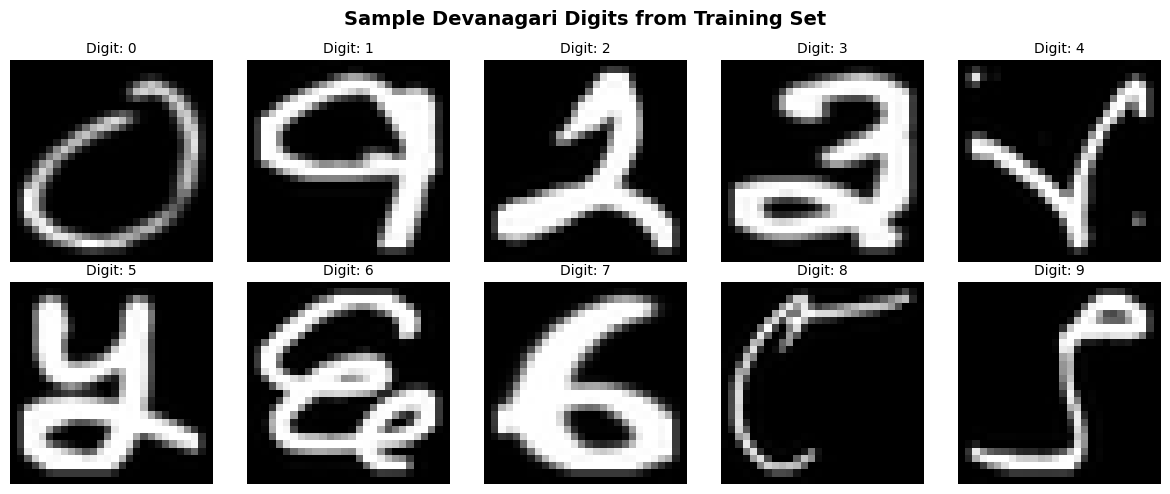

In [5]:
# Visualise sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Devanagari Digits from Training Set", fontsize=14, fontweight="bold")

for digit in range(10):
    # Find first occurrence of this class
    idx = np.where(np.argmax(y_train, axis=1) == digit)[0][0]
    ax  = axes[digit // 5][digit % 5]
    ax.imshow(x_train[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    ax.set_title(f"Digit: {digit}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Task 2 — Build the FCN Model

Architecture:
- **Input**: 28×28×1 flattened to 784 neurons  
- **Hidden layer 1**: 64 neurons, Sigmoid  
- **Hidden layer 2**: 128 neurons, Sigmoid  
- **Hidden layer 3**: 256 neurons, Sigmoid  
- **Output layer**: 10 neurons, Softmax  

In [6]:
#  Build Sequential FCN
def build_fcn_model(input_shape=(28, 28, 1), num_classes=10):
    """
    Builds a Fully Connected Neural Network (FCN) using the Keras
    high-level Sequential API.

    Architecture:
        Flatten → Dense(64, sigmoid) → Dense(128, sigmoid)
        → Dense(256, sigmoid) → Dense(10, softmax)
    """
    model = keras.Sequential(
        [
            # Input specification
            keras.Input(shape=input_shape, name="input_layer"),

            # Flatten 28x28x1 → 784-dimensional vector
            layers.Flatten(name="flatten"),

            # Hidden Layer 1
            layers.Dense(64,  activation="sigmoid", name="hidden_1"),

            # Hidden Layer 2
            layers.Dense(128, activation="sigmoid", name="hidden_2"),

            # Hidden Layer 3
            layers.Dense(256, activation="sigmoid", name="hidden_3"),

            # Output Layer — 10 classes (Devanagari digits 0-9)
            layers.Dense(num_classes, activation="softmax", name="output_layer"),
        ],
        name="Devanagari_FCN",
    )
    return model


model = build_fcn_model()


In [7]:
model.summary()

Model: "Devanagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3 — Compile the Model

- **Optimizer**: Adam (adaptive learning rate, default lr = 0.001)  
- **Loss**: `categorical_crossentropy` (labels are one-hot encoded)  
- **Metric**: Accuracy

In [8]:
# Compile
# Adam with default learning rate 0.001 is used as specified in the task.
# categorical_crossentropy is appropriate because labels are one-hot encoded.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled successfully.")
print(f"  Optimizer : Adam (lr=0.01)")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully.
  Optimizer : Adam (lr=0.01)
  Loss      : categorical_crossentropy
  Metrics   : accuracy


## Task 4 — Train the Model

- **Batch size**: 128  
- **Epochs**: 20  
- **Validation split**: 20%  
- **Callbacks**: `ModelCheckpoint` + `EarlyStopping`

In [9]:
#  Hyperparameters
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.20

# Callbacks
# ModelCheckpoint: saves the best model (lowest val_loss) during training
checkpoint_cb = ModelCheckpoint(
    filepath="best_devanagari_fcn.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

# EarlyStopping: halts training if val_loss does not improve for 5 epochs
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,   # restores weights from the best epoch on stop
    verbose=1,
)

# Train
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1,
)

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5120 - loss: 1.3096
Epoch 1: val_loss improved from None to 15.72534, saving model to best_devanagari_fcn.h5



Epoch 1: finished saving model to best_devanagari_fcn.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7489 - loss: 0.6844 - val_accuracy: 0.0000e+00 - val_loss: 15.7253
Epoch 2/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9554 - loss: 0.1404
Epoch 2: val_loss improved from 15.72534 to 14.83124, saving model to best_devanagari_fcn.h5



Epoch 2: finished saving model to best_devanagari_fcn.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9596 - loss: 0.1304 - val_accuracy: 0.0000e+00 - val_loss: 14.8312
Epoch 3/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9726 - loss: 0.0884
Epoch 3: val_loss improved from 14.83124 to 14.82786, saving model to best_devanagari_fcn.h5



Epoch 3: finished saving model to best_devanagari_fcn.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9736 - loss: 0.0843 - val_accuracy: 0.0000e+00 - val_loss: 14.8279
Epoch 4/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9781 - loss: 0.0628
Epoch 4: val_loss did not improve from 14.82786
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9799 - loss: 0.0614 - val_accuracy: 0.0000e+00 - val_loss: 14.8610
Epoch 5/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9871 - loss: 0.0403
Epoch 5: val_loss did not improve from 14.82786
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9853 - loss: 0.0455 - val_accuracy: 0.0000e+00 - val_loss: 15.9579
Epoch 6/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9838 - loss: 0.0492
Epoch 6: val_loss did not improve from 14.82786
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9843 - loss: 0.0487 - val_accuracy: 0.0000e+00 - val_loss: 15.9457
Epoch 7/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

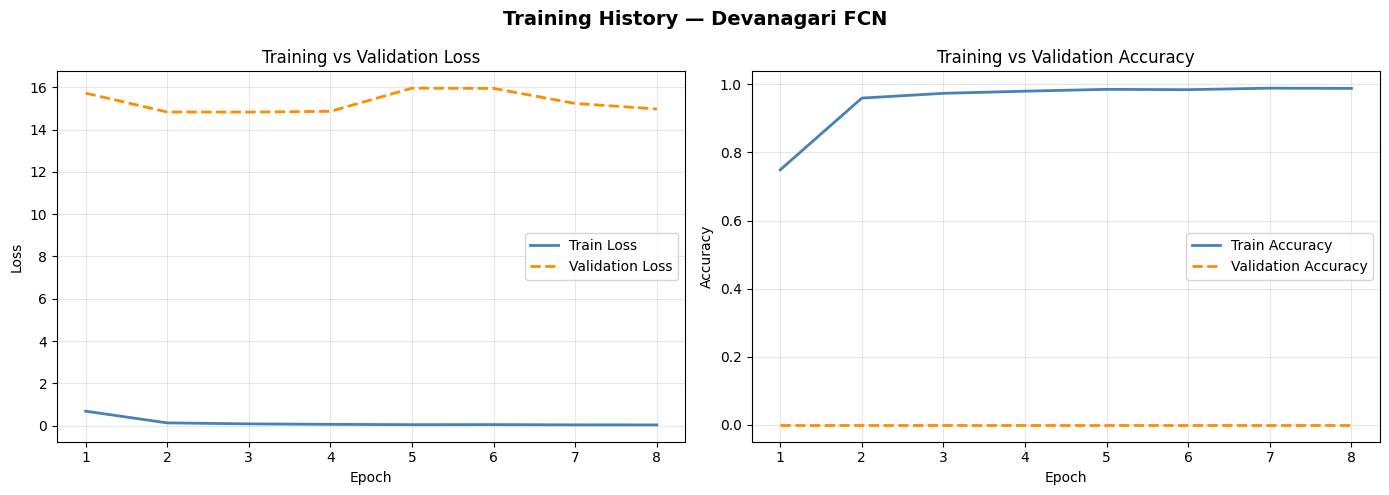

Plot saved as training_history.png


In [10]:
#  Visualise Training History
epochs_ran = len(history.history["loss"])
epoch_axis = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — Devanagari FCN", fontsize=14, fontweight="bold")

# Loss curves
ax1.plot(epoch_axis, history.history["loss"],     label="Train Loss",      color="steelblue",  linewidth=2)
ax1.plot(epoch_axis, history.history["val_loss"], label="Validation Loss", color="darkorange", linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epoch_axis, history.history["accuracy"],     label="Train Accuracy",      color="steelblue",  linewidth=2)
ax2.plot(epoch_axis, history.history["val_accuracy"], label="Validation Accuracy", color="darkorange", linewidth=2, linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training vs Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as training_history.png")

## Task 5 — Evaluate the Model on the Test Set

In [11]:
#  Evaluate on held-out test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")


94/94 - 1s - 10ms/step - accuracy: 0.7693 - loss: 3.0795
  Test Loss     : 3.0795
  Test Accuracy : 76.93%


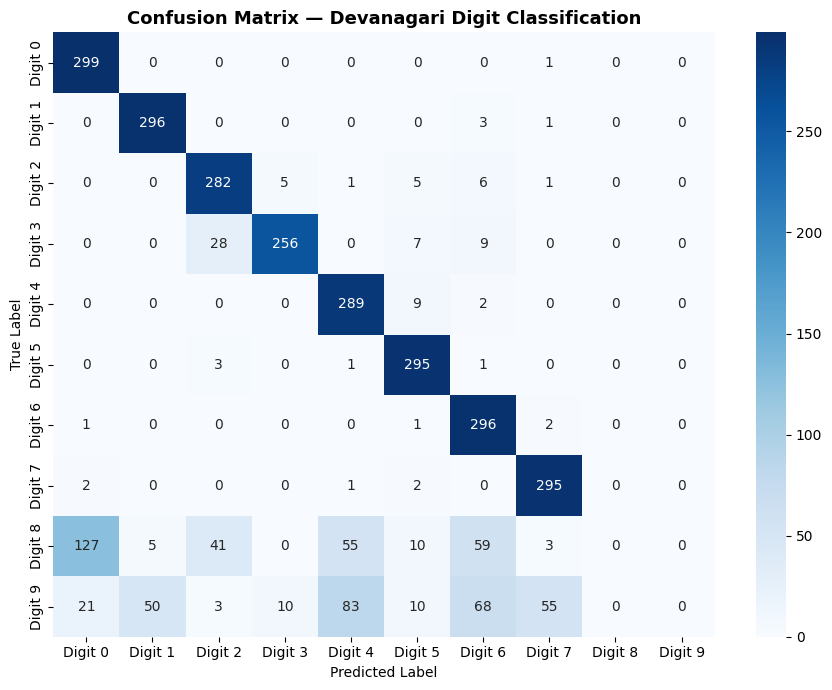

Confusion matrix saved as confusion_matrix.png


In [12]:
#  Confusion Matrix
y_pred_probs  = model.predict(x_test, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Digit {i}" for i in range(10)],
    yticklabels=[f"Digit {i}" for i in range(10)],
    ax=ax,
)
ax.set_title("Confusion Matrix — Devanagari Digit Classification", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

In [13]:
#  Per-class Classification Report
target_names = [f"Digit {i}" for i in range(10)]
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names))

              precision    recall  f1-score   support

     Digit 0       0.66      1.00      0.80       300
     Digit 1       0.84      0.99      0.91       300
     Digit 2       0.79      0.94      0.86       300
     Digit 3       0.94      0.85      0.90       300
     Digit 4       0.67      0.96      0.79       300
     Digit 5       0.87      0.98      0.92       300
     Digit 6       0.67      0.99      0.80       300
     Digit 7       0.82      0.98      0.90       300
     Digit 8       0.00      0.00      0.00       300
     Digit 9       0.00      0.00      0.00       300

    accuracy                           0.77      3000
   macro avg       0.63      0.77      0.69      3000
weighted avg       0.63      0.77      0.69      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Task 6 — Save and Load the Model

In [14]:
# Save the trained model
# .h5 format as required by the worksheet specification
SAVE_PATH = "devanagari_fcn_model.h5"
model.save(SAVE_PATH)
print(f"Model saved to: {SAVE_PATH}")

Model saved to: devanagari_fcn_model.h5


In [15]:
# ── Load the saved model ──────────────────────────────────────────────────────
loaded_model = keras.models.load_model(SAVE_PATH)
print(f"Model loaded from: {SAVE_PATH}")

# Re-evaluate to confirm identical performance
reloaded_loss, reloaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nReloaded Model — Test Loss: {reloaded_loss:.4f} | Test Accuracy: {reloaded_acc * 100:.2f}%")

Model loaded from: devanagari_fcn_model.h5
94/94 - 1s - 6ms/step - accuracy: 0.7693 - loss: 3.0795

Reloaded Model — Test Loss: 3.0795 | Test Accuracy: 76.93%


## Task 7 — Make Predictions on Test Images

In [16]:
# Run predictions using the loaded model
predictions     = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)   # class with highest probability
true_labels      = np.argmax(y_test, axis=1)

# Quick accuracy check
correct = np.sum(predicted_labels == true_labels)
print(f"Correctly classified : {correct} / {len(true_labels)}  ({correct / len(true_labels) * 100:.2f}%)")

Correctly classified : 2308 / 3000  (76.93%)


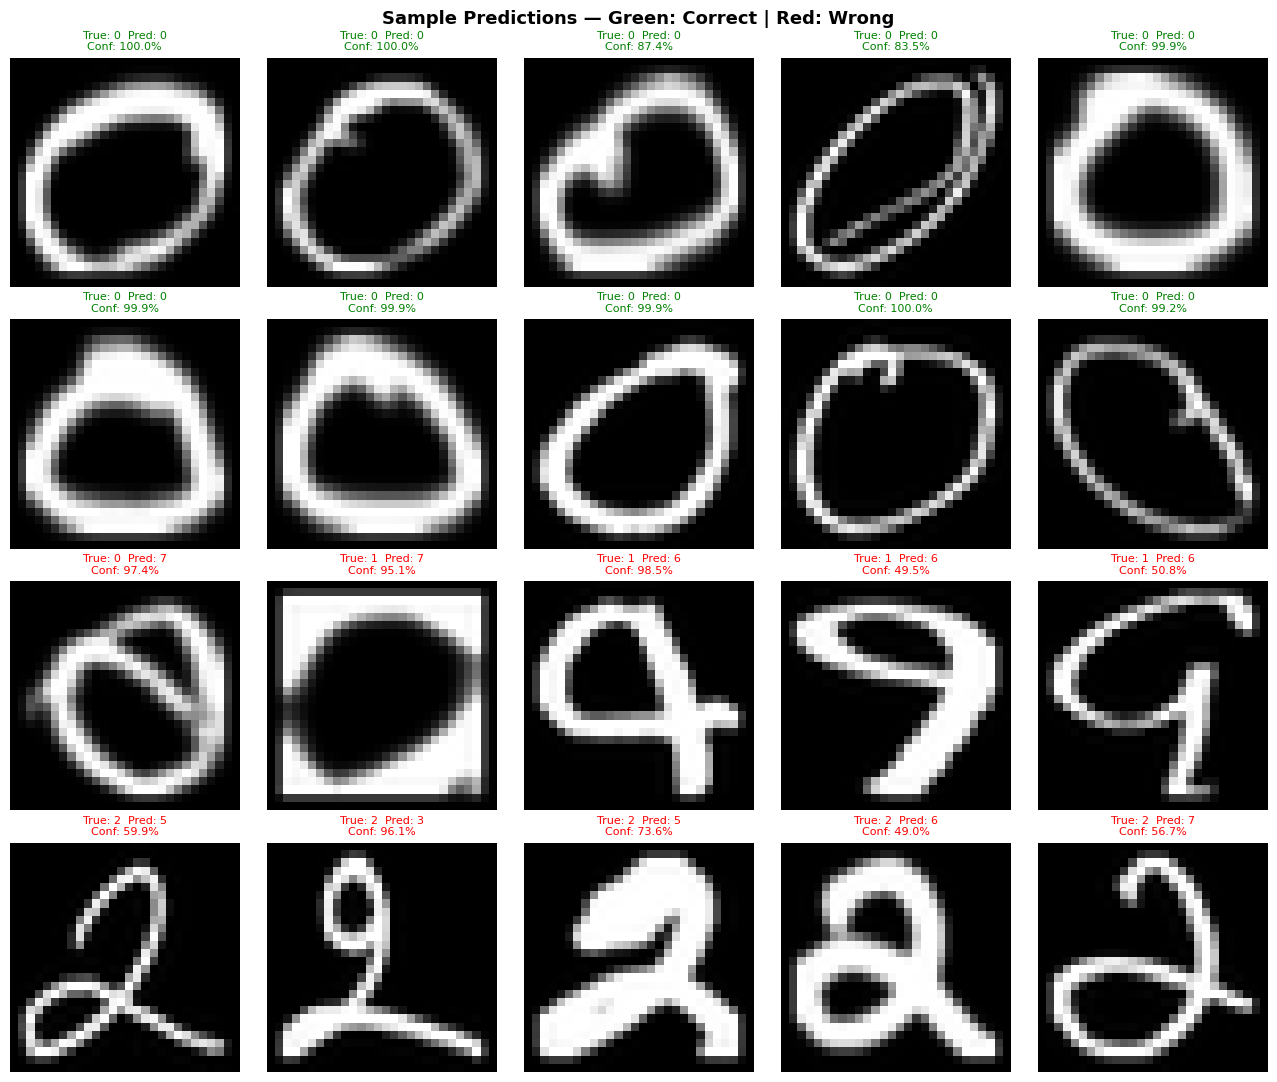

Predictions plot saved as predictions_sample.png


In [17]:
# Visualise: correct predictions (green) + wrong predictions (red)
fig, axes = plt.subplots(4, 5, figsize=(13, 11))
fig.suptitle("Sample Predictions — Green: Correct | Red: Wrong",
             fontsize=13, fontweight="bold")

# Show 10 correct + 10 wrong predictions
correct_idx = np.where(predicted_labels == true_labels)[0][:10]
wrong_idx   = np.where(predicted_labels != true_labels)[0][:10]
indices     = list(correct_idx) + list(wrong_idx)

for plot_pos, idx in enumerate(indices):
    ax      = axes[plot_pos // 5][plot_pos % 5]
    is_correct = (predicted_labels[idx] == true_labels[idx])
    color   = "green" if is_correct else "red"

    ax.imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    ax.set_title(
        f"True: {true_labels[idx]}  Pred: {predicted_labels[idx]}\n"
        f"Conf: {predictions[idx][predicted_labels[idx]] * 100:.1f}%",
        fontsize=8,
        color=color,
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("predictions_sample.png", dpi=150, bbox_inches="tight")
plt.show()
print("Predictions plot saved as predictions_sample.png")

In [20]:
#  Predict a single image (example)
sample_index = 0   # change this to inspect any test sample

single_image = x_test[sample_index:sample_index + 1]   # shape (1, 28, 28, 1)
single_pred  = loaded_model.predict(single_image, verbose=0)

predicted_digit = np.argmax(single_pred, axis=1)[0]
true_digit      = np.argmax(y_test[sample_index])
confidence      = single_pred[0][predicted_digit] * 100

print(f"Sample index     : {sample_index}")
print(f"True label       : {true_digit}")
print(f"Predicted label  : {predicted_digit}")
print(f"Confidence       : {confidence:.2f}%")
print(f"Class probabilities (rounded):")
for cls, prob in enumerate(single_pred[0]):
    bar = "█" * int(prob * 30)
    print(f"  Digit {cls}: {prob * 100:6.2f}%  {bar}")

Sample index     : 0
True label       : 0
Predicted label  : 0
Confidence       : 99.97%
Class probabilities (rounded):
  Digit 0:  99.97%  █████████████████████████████
  Digit 1:   0.01%  
  Digit 2:   0.00%  
  Digit 3:   0.00%  
  Digit 4:   0.00%  
  Digit 5:   0.00%  
  Digit 6:   0.00%  
  Digit 7:   0.01%  
  Digit 8:   0.00%  
  Digit 9:   0.00%  
